In [1]:
# Set up SAM2 for segmentation

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from sam2.sam2_image_predictor import SAM2ImagePredictor # initially used SAM2AutomaticMaskGenerator, but was too slow

device = torch.device("mps")

CHECKPOINT = "checkpoints/sam2_hiera_large.pt"
MODEL_CFG = "configs/sam2/sam2_hiera_l.yaml"

sam2_model = build_sam2(MODEL_CFG, CHECKPOINT, device=device)

predictor = SAM2ImagePredictor(sam2_model)
print("Predictor loaded!")

Predictor loaded!


In [24]:
def segment(image_path, output_path=None):
    """
    Take in an image, run SAM2, and return best person mask
    """
    # Load image
    image = Image.open(image_path).convert("RGB")
    image_array = np.array(image)

    # Get masks
    l, w = image_array.shape[:2] # length, width
    input_pts = np.array([
        [w // 2, l // 2], # center of photo 
        [w // 2, 2 * l // 5], # upper body 
        [w // 2, 4 * l // 5], # lower body 
        [w // 3, l // 2], # left side of body 
        [2 * w // 3, l // 2], # right side of body 
        [2, 2], # top-left corner, background 
        [w - 2, l - 2], # bottom-right corner, background 
        [2, l - 2], # bottom-left corner, background 
        [w - 2, 2] # top-right corner, background 
    ])
    labels = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0]) # last four input points are background
    predictor.set_image(image_array)
    masks_raw, scores, low_res_masks_logits = predictor.predict(point_coords=input_pts, point_labels=labels)
    masks = [{'segmentation': masks_raw[i].astype(bool), 'area': masks_raw[i].sum()} for i in range(len(masks_raw))]

    # Sort by mask area
    masks = sorted(masks, key=lambda m: m['area'], reverse=True)

    # Select mask that most likely matches the human figure
    # (i.e. large area but not the largest [would likely be the entire background])
    area = image_array.shape[0] * image_array.shape[1] # height * width
    silhouette_mask = None

    for mask in masks:
        coverage = mask['area'] / area
        if coverage < 0.70 : # max out at 70% coverage bc don't want background; want biggest area otherwise; masks already sorted by area
            silhouette_mask = mask
            break
    if silhouette_mask is None: # take largest area otherwise 
        silhouette_mask = masks[0]

    silhouette = silhouette_mask['segmentation']

    # fill holes
    silhouette_uint8 = silhouette.astype(np.uint8) * 255
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10, 10)) # make a kernel in ellipse size (humans not boxy) to pass over
    silhouette_uint8 = cv2.morphologyEx(silhouette_uint8, cv2.MORPH_CLOSE, k)

    # get rid of small background noise 
    n_blobs, labels, stats, coords = cv2.connectedComponentsWithStats(silhouette_uint8)
    block_areas = stats[1:, cv2.CC_STAT_AREA] # get array of areas for every block (excl. background)
    biggest_label = 1 + np.argmax(block_areas) # select idx of largest area (silhouette)
    silhouette_uint8 = np.where(labels == biggest_label, 255, 0).astype(np.uint8) # if label belongs to silhouette, set to 255
    silhouette = silhouette_uint8.astype(bool)
    
    # Put mask over image
    masked_img = image_array.copy()
    masked_img[~silhouette] = 0  # black out background

    # Plot results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image_array)
    axes[0].set_title("Original")
    axes[0].axis('off')

    axes[1].imshow(silhouette, cmap='gray')
    axes[1].set_title("Raw Mask")
    axes[1].axis('off')

    axes[2].imshow(masked_img)
    axes[2].set_title("Human Silhouette")
    axes[2].axis('off')

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path)
    plt.show()

    return silhouette, masked_img

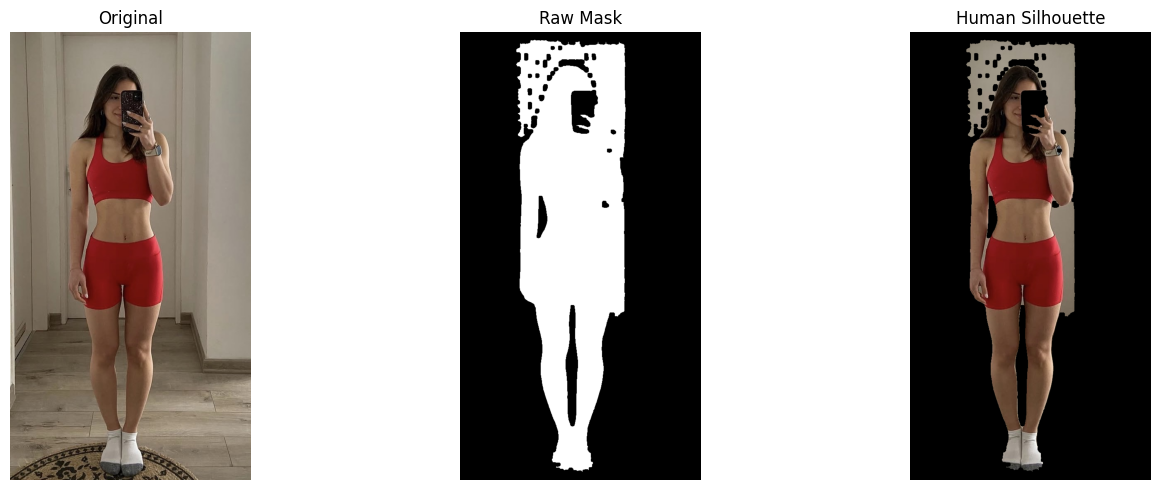

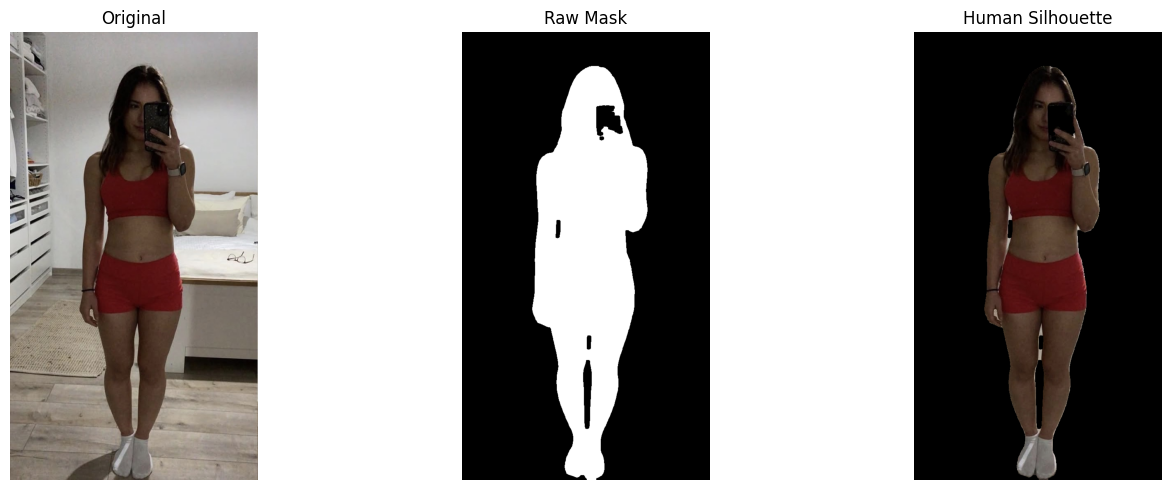

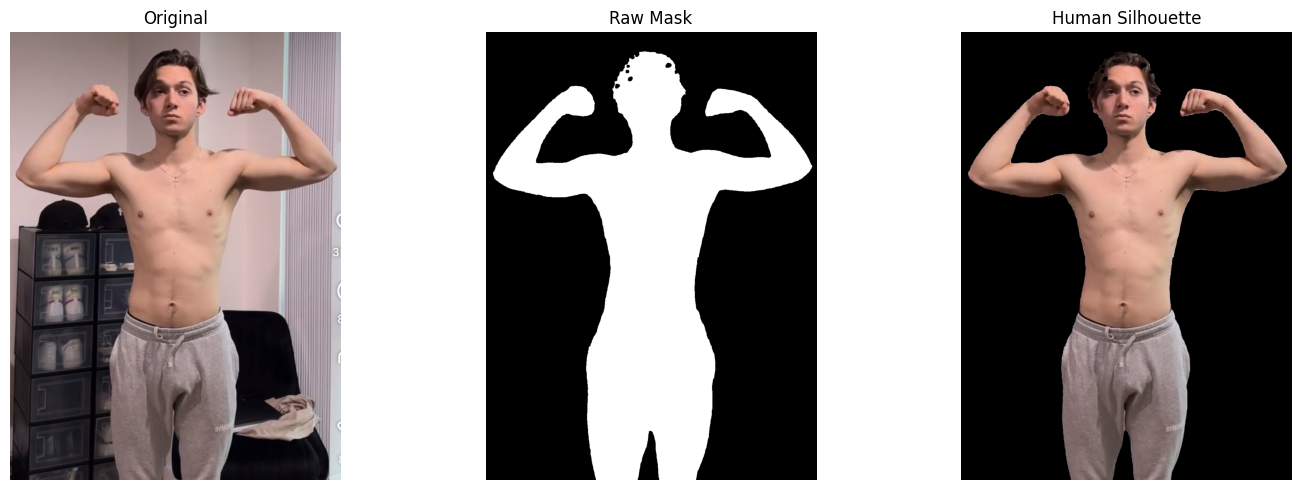

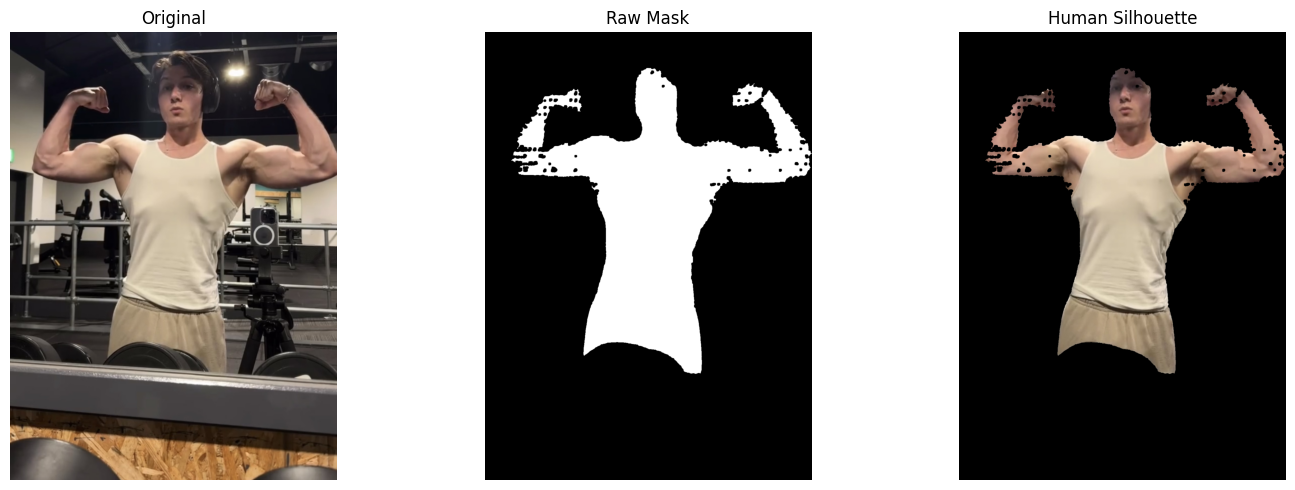

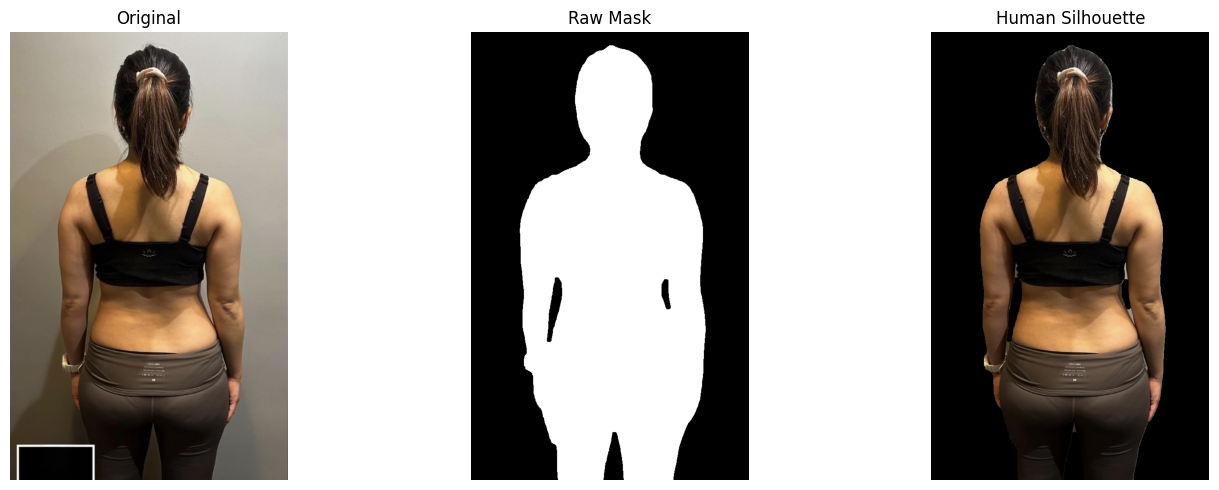

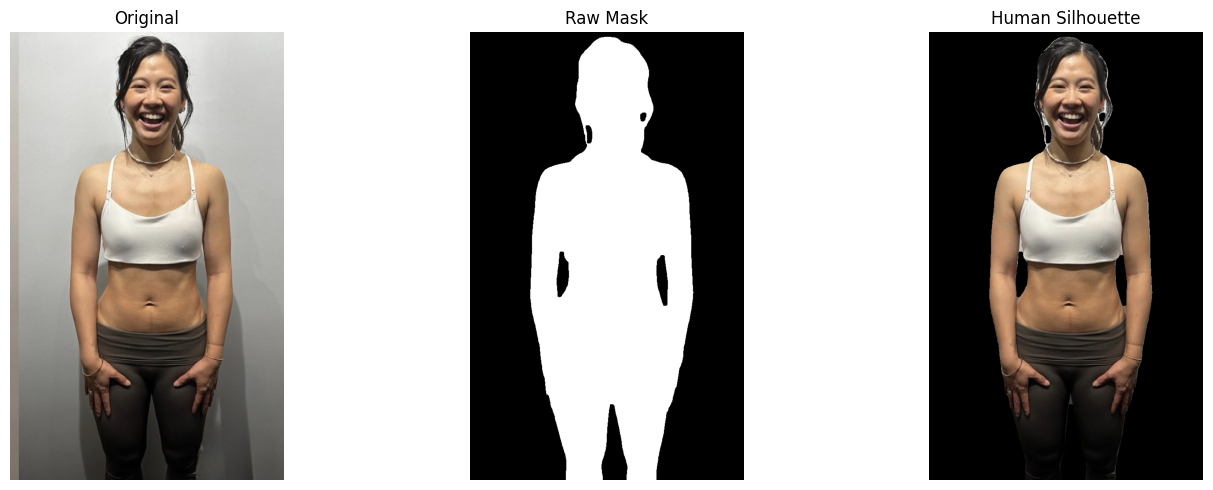

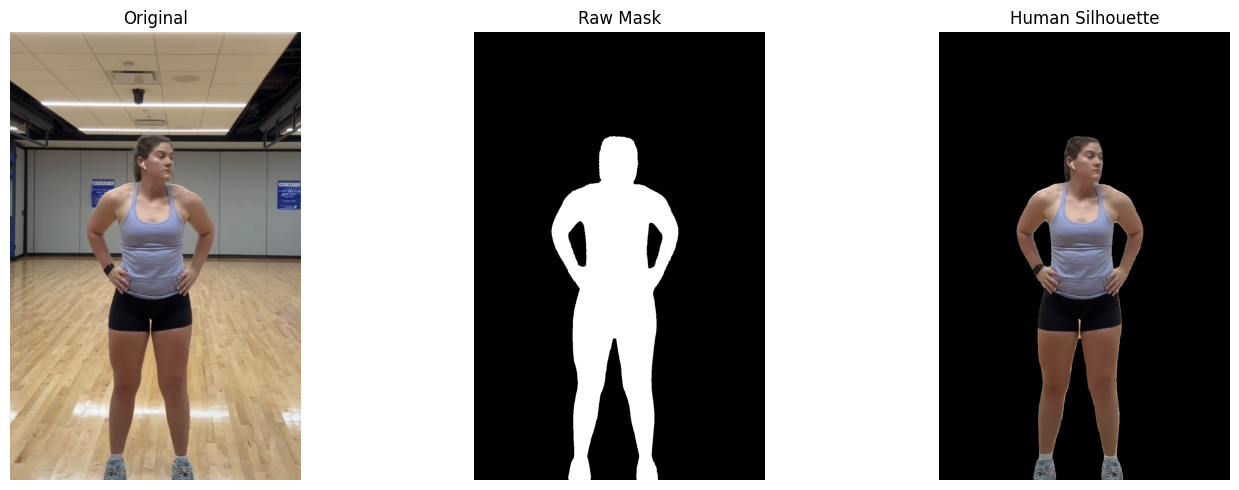

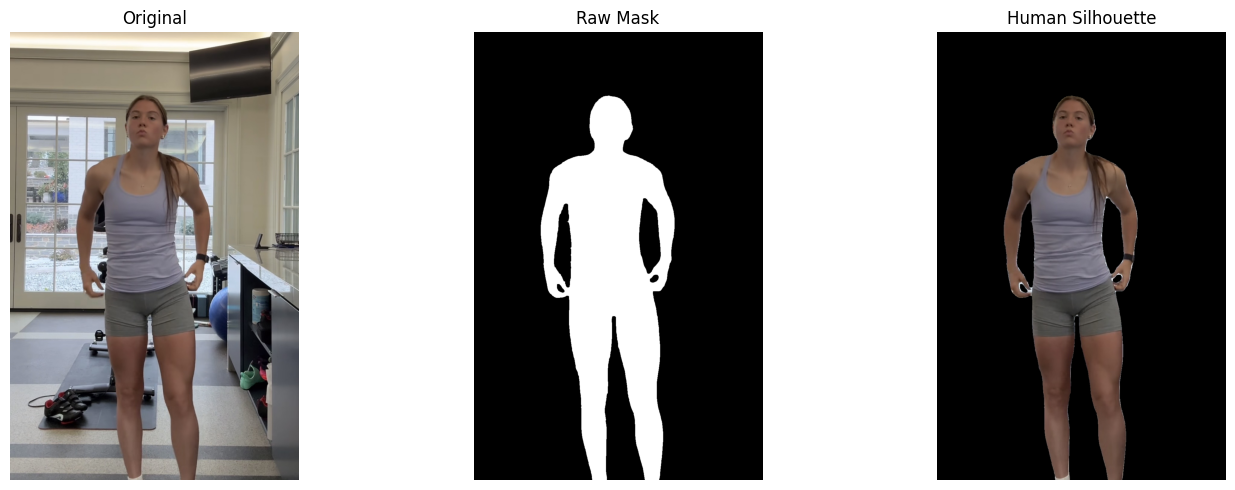

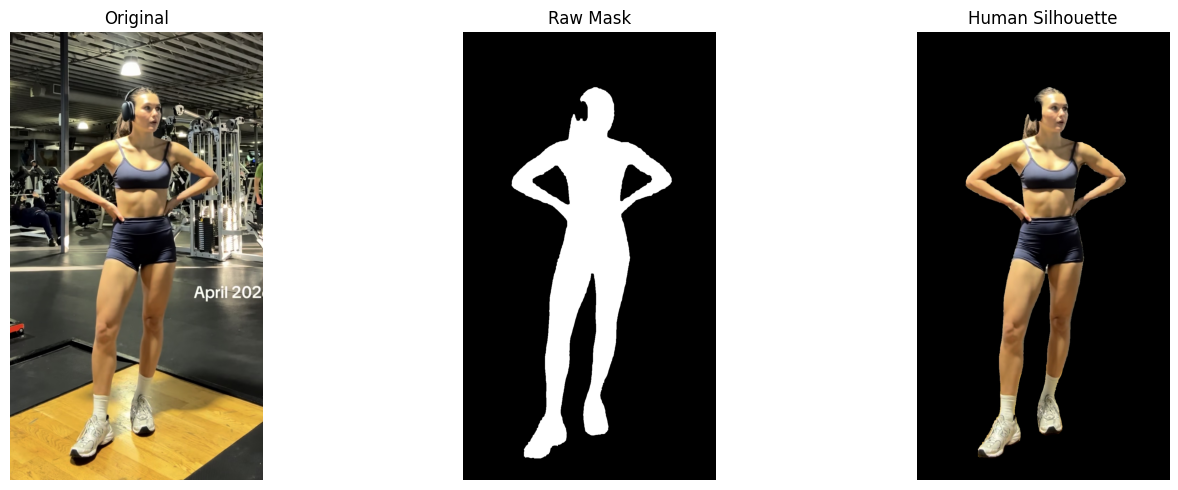

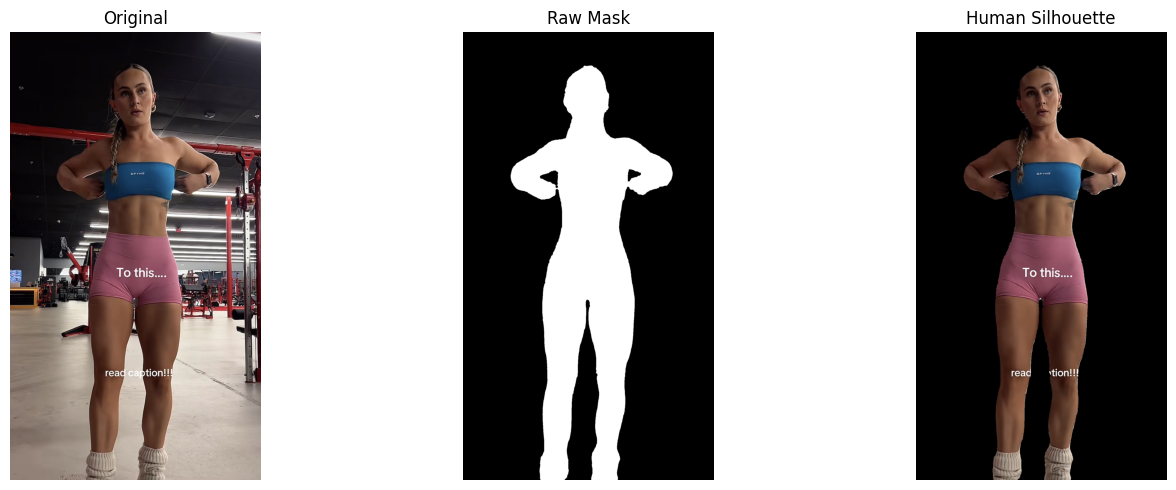

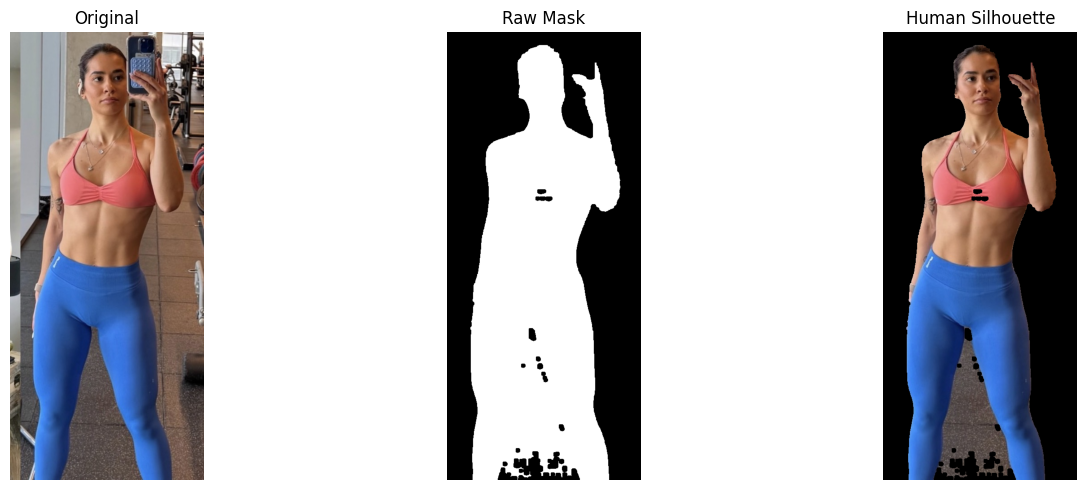

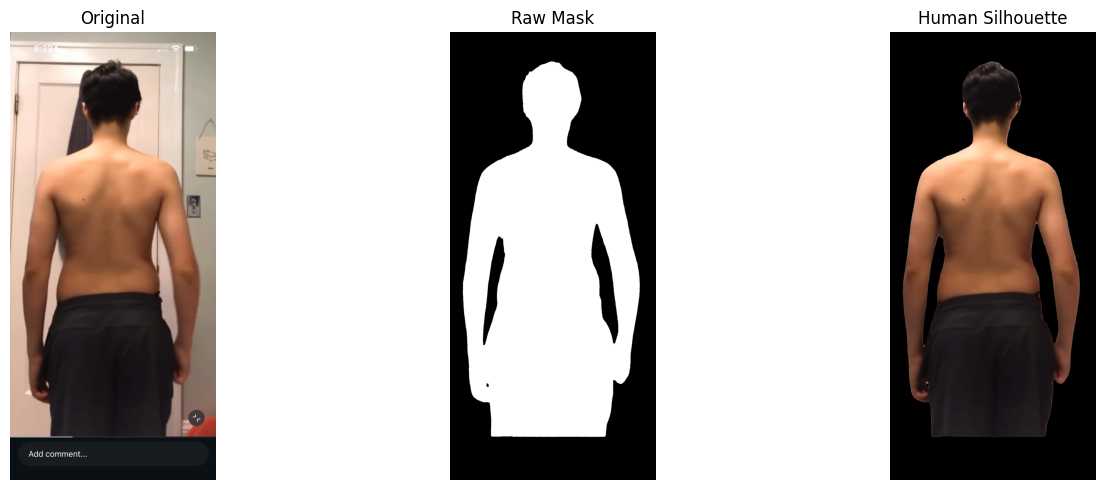

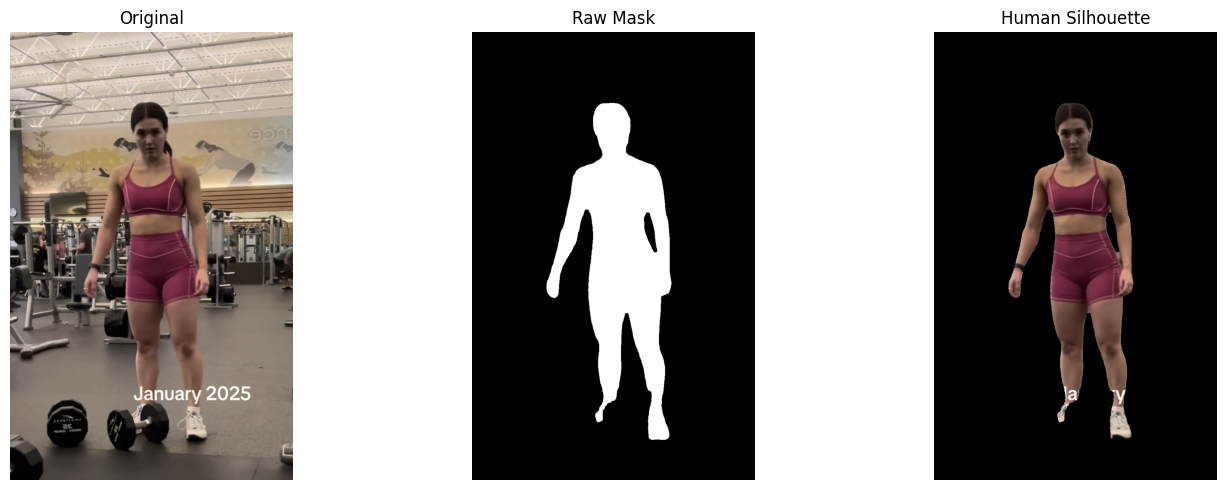

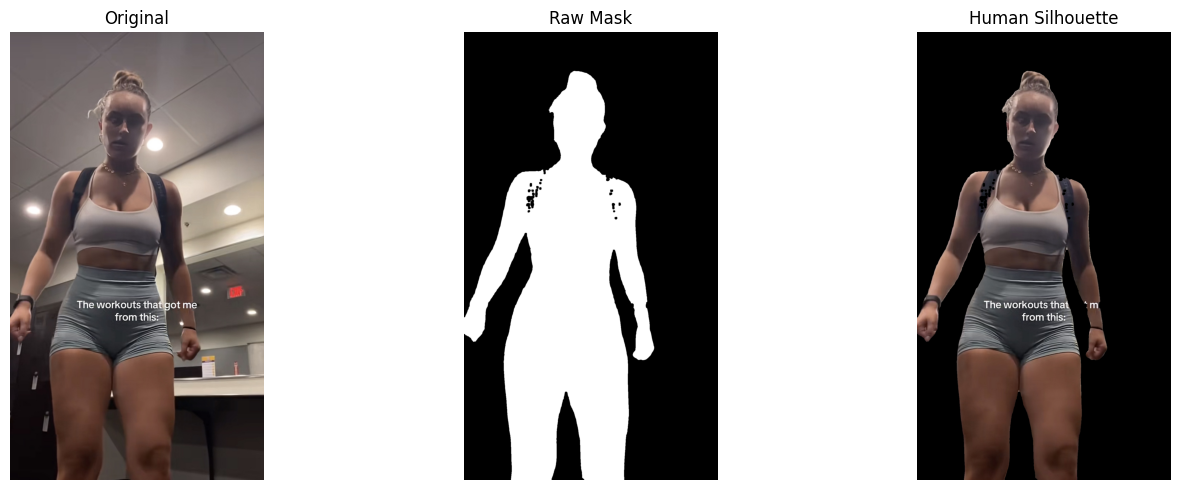

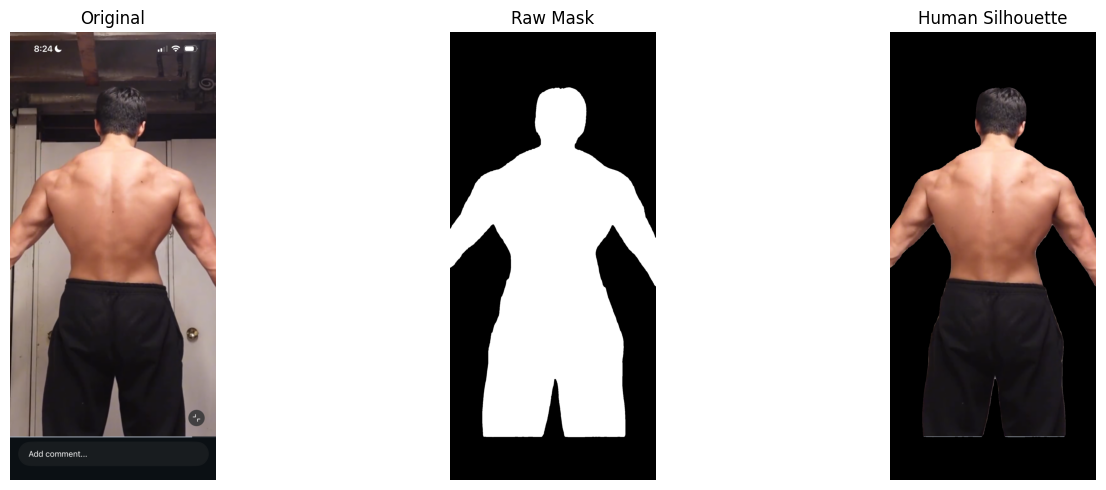

In [25]:
# apply segment() to all photos

from pathlib import Path 

folder_path = Path("/Users/hannahlatif/Documents/CS131/Final_Project/Milestone/og_photos")
for img_path in folder_path.glob("*.jpg"):
    segment(img_path, Path(f"/Users/hannahlatif/Documents/CS131/Final_Project/Milestone/after/{img_path.stem}_segmented{img_path.suffix}"))


Pose Normalization

In [ ]:
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
print("MediaPipe version:", mp.__version__)
print("BlazePose loaded!")

0.10.35
